# Constrained and unconstrained mean-field calculations

By default `get_mean_field_hamiltonian` lets every Wick-contraction channel (charge order,
magnetism, pairing, ...) develop freely. Passing `constrains=[...]` (e.g. `"no_charge"`,
`"no_SC"`) forcibly zeroes out specific channels every iteration, useful to isolate the physics of
a single instability or to forbid an unwanted symmetry breaking. Below, a honeycomb bilayer-like
flake at half filling is converged with and without a `"no_charge"` constraint: without it, the SCF
develops a charge-disproportionated state; with it, only the bands shift rigidly and stay
charge-uniform.

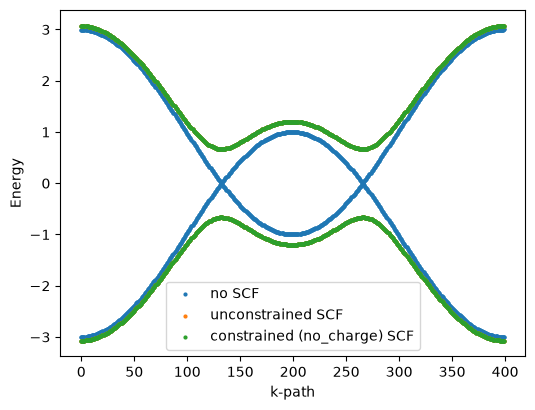

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.honeycomb_lattice()
g = g.get_supercell(1)
h = g.get_hamiltonian()
U = 3.0
filling = 0.5

h_free = h.get_mean_field_hamiltonian(U=U,filling=filling,mf="random")
h_constrained = h.get_mean_field_hamiltonian(U=U,filling=filling,mf="random",
                                              constrains=["no_charge"])

(k0,e0) = h.get_bands()
(k1,e1) = h_free.get_bands()
(k2,e2) = h_constrained.get_bands()

plt.figure(figsize=(6,4.5))
plt.scatter(k0,e0,s=4,label="no SCF")
plt.scatter(k1,e1,s=4,label="unconstrained SCF")
plt.scatter(k2,e2,s=4,label="constrained (no_charge) SCF")
plt.legend()
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.show()